# NACA Airfoil Surrogate Model — Exploratory Data Analysis

This notebook explores the dataset generated by running XFoil simulations 
across 163 NACA 4-digit airfoils at three Reynolds numbers (0.5M, 1.0M, 2.0M).
The goal is to understand the aerodynamic trends in the data before building 
a machine learning surrogate model.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../data/xfoil_dataset.csv')
df = pd.read_csv('../data/xfoil_dataset.csv', dtype={'naca': str})
df['naca'] = df['naca'].str.zfill(4)

print(f"Dataset shape: {df.shape}")
print(f"Unique airfoils: {df['naca'].nunique()}")
print(f"Reynolds numbers: {sorted(df['re'].unique())}")
print(f"\nColumn stats:")
df.describe()

Dataset shape: (20113, 6)
Unique airfoils: 163
Reynolds numbers: [np.float64(500000.0), np.float64(1000000.0), np.float64(2000000.0)]

Column stats:


,re,aoa,cl,cd,cm
count,2.011300e+04,20113.000000,20113.000000,20113.000000,20113.000000
mean,1.199920e+06,2.359544,0.477197,0.014042,-0.043870
std,6.258495e+05,7.186620,0.733667,0.013168,0.032210
min,5.000000e+05,-10.000000,-1.137207,0.001247,-0.127075
25%,5.000000e+05,-4.000000,-0.158543,0.007889,-0.065125
50%,1.000000e+06,2.500000,0.522928,0.010407,-0.039770
75%,2.000000e+06,8.500000,1.144874,0.015318,-0.020029
max,2.000000e+06,14.500000,1.842476,0.190042,0.042966


## NACA 2412 Polar Curves
The NACA 2412 shows the expected lift curve behavior — linear increase with 
angle of attack, with onset of stall visible near 13-14°. Higher Reynolds 
numbers produce slightly more lift and significantly less drag, consistent 
with attached boundary layer behavior at higher Re.

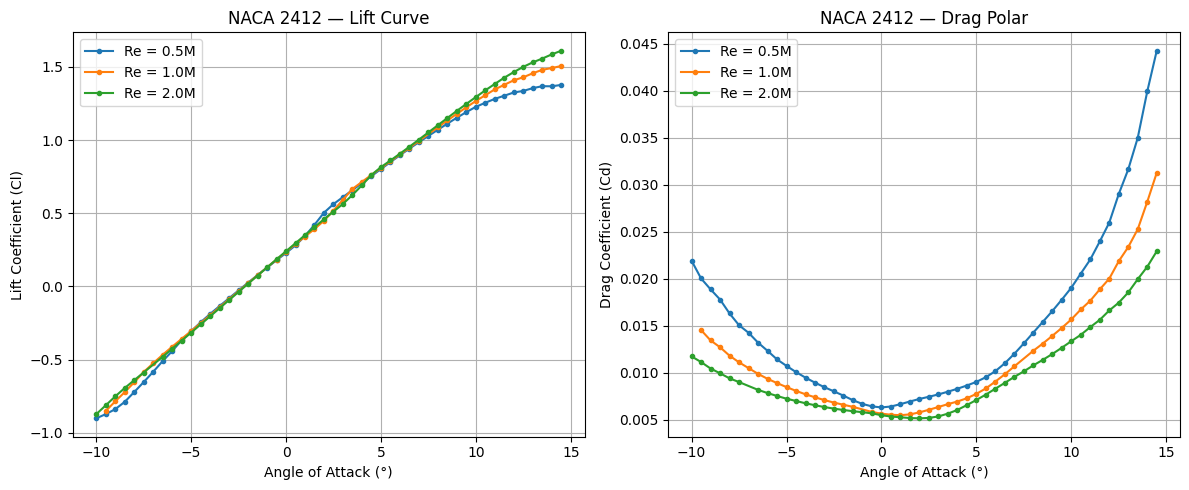

In [5]:
# Lift curve for NACA 2412 at different Reynolds numbers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

airfoil = '2412'
data = df[df['naca'] == airfoil]

for re, group in data.groupby('re'):
    label = f"Re = {re/1e6:.1f}M"
    axes[0].plot(group['aoa'], group['cl'], marker='o', markersize=3, label=label)
    axes[1].plot(group['aoa'], group['cd'], marker='o', markersize=3, label=label)

axes[0].set_xlabel('Angle of Attack (°)')
axes[0].set_ylabel('Lift Coefficient (Cl)')
axes[0].set_title(f'NACA {airfoil} — Lift Curve')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Angle of Attack (°)')
axes[1].set_ylabel('Drag Coefficient (Cd)')
axes[1].set_title(f'NACA {airfoil} — Drag Polar')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../data/naca2412_polar.png', dpi=150)
plt.show()

## Effect of Thickness
Thickness has minimal effect on the lift curve slope for symmetric airfoils, 
consistent with thin airfoil theory. However, thinner airfoils (0006, 0008) 
show sharper stall behavior, while thicker profiles stall more gradually.

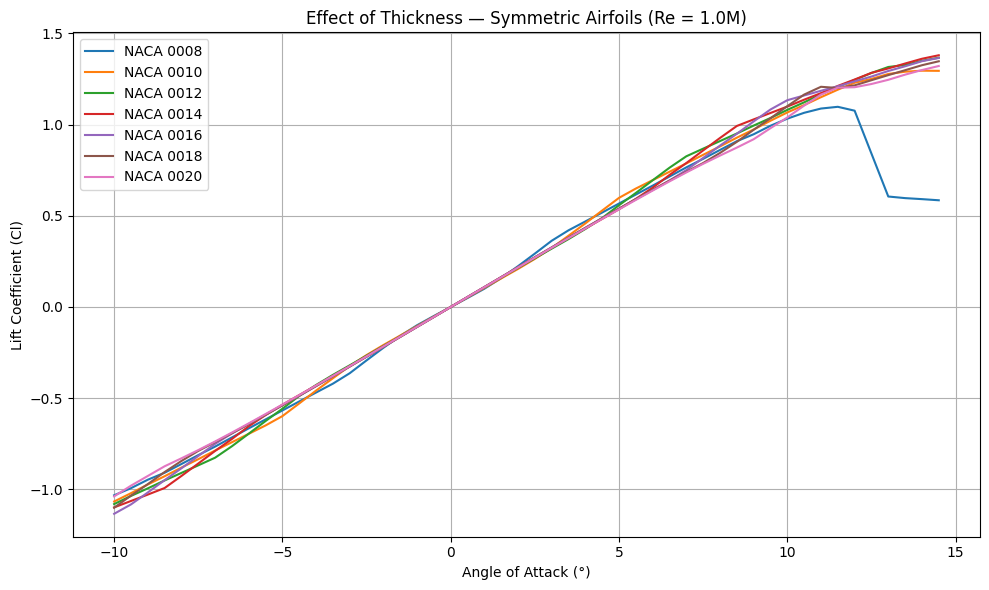

In [7]:
# Effect of thickness on symmetric airfoils (Re = 1M)
fig, ax = plt.subplots(figsize=(10, 6))

symmetric = ['0006', '0008', '0010', '0012', '0014', '0016', '0018', '0020']

for naca in symmetric:
    data = df[(df['naca'] == naca) & (df['re'] == 1e6)]
    if len(data) > 0:
        ax.plot(data['aoa'], data['cl'], label=f'NACA {naca}')

ax.set_xlabel('Angle of Attack (°)')
ax.set_ylabel('Lift Coefficient (Cl)')
ax.set_title('Effect of Thickness — Symmetric Airfoils (Re = 1.0M)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('../data/thickness_comparison.png', dpi=150)
plt.show()

## Effect of Camber
Camber shifts the lift curve upward, increasing the zero-lift angle of attack 
in the negative direction and raising maximum Cl. A cambered airfoil generates 
lift even at 0° angle of attack, which is why most subsonic aircraft wings use 
cambered profiles.

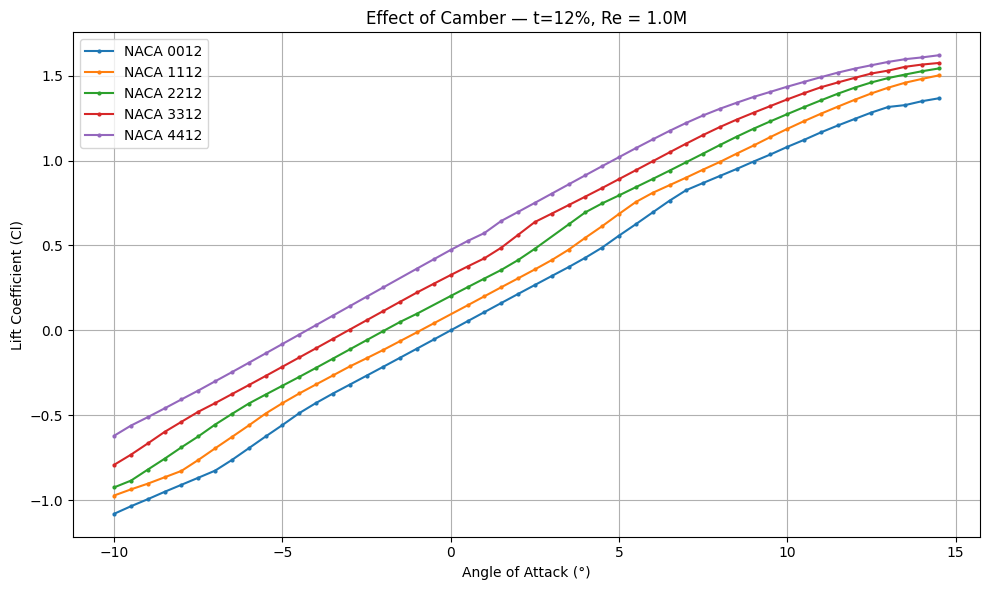

In [8]:
# Effect of camber — varying m, fixed thickness t=12, fixed Re=1M
fig, ax = plt.subplots(figsize=(10, 6))

cambered = ['0012', '1112', '2212', '3312', '4412']

for naca in cambered:
    data = df[(df['naca'] == naca) & (df['re'] == 1e6)]
    if len(data) > 0:
        ax.plot(data['aoa'], data['cl'], marker='o', markersize=2, label=f'NACA {naca}')

ax.set_xlabel('Angle of Attack (°)')
ax.set_ylabel('Lift Coefficient (Cl)')
ax.set_title('Effect of Camber — t=12%, Re = 1.0M')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('../data/camber_comparison.png', dpi=150)
plt.show()

## Lift-to-Drag Ratio
Each airfoil has a distinct optimal angle of attack where L/D is maximized. 
Higher camber airfoils achieve better peak L/D ratios, but only within a 
narrower AoA range. The symmetric 0012 has a broader efficiency band but 
lower peak performance — a classic design tradeoff.

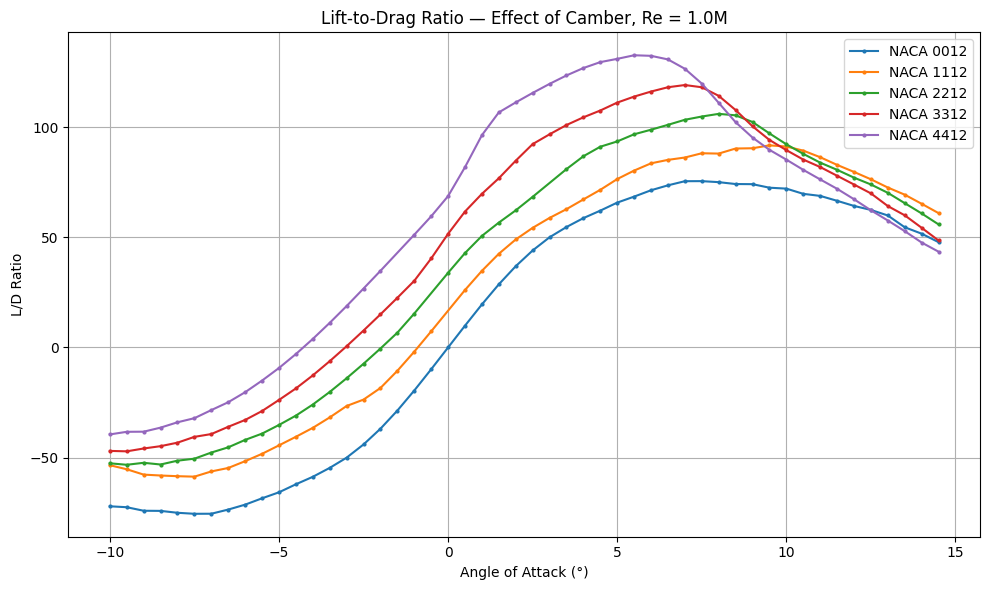

In [9]:
# L/D ratio comparison
fig, ax = plt.subplots(figsize=(10, 6))

for naca in cambered:
    data = df[(df['naca'] == naca) & (df['re'] == 1e6)].copy()
    if len(data) > 0:
        data['ld'] = data['cl'] / data['cd']
        ax.plot(data['aoa'], data['ld'], marker='o', markersize=2, label=f'NACA {naca}')

ax.set_xlabel('Angle of Attack (°)')
ax.set_ylabel('L/D Ratio')
ax.set_title('Lift-to-Drag Ratio — Effect of Camber, Re = 1.0M')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('../data/ld_ratio.png', dpi=150)
plt.show()